In [91]:
import math
import numpy as np
import matplotlib.pyplot as plt
import random
%matplotlib inline

In [110]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda : None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad

        out._backward = _backward
        return out

    def __sub__(self, other):
        return self + (-other)

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward
        return out

    def __rmul__(self, other): # other * self
        return self * other

    def __radd__(self, other): # other + self
        return self + other

    def __truediv__(self, other):
        return self * other**-1
    
    def __pow__(self, other):
        #other = other if isinstance(other, Value) else Value(other)
        assert isinstance(other, (int, float))
        out = Value(self.data**other, (self, ), f'**{other}')

        def _backward():
            self.grad = (other * self.data**(other-1)) * out.grad

        out._backward = _backward
        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad

        out._backward = _backward
        return out

    def tanh(self):
        n = self.data
        t = (math.exp(2*n) - 1 ) / (math.exp(2*n) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1- t**2) * out.grad
            
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()

        def build_topo(v: Value):
            if v not in visited:
                visited.add(v)
                for c in v._prev:
                    build_topo(c)
                topo.append(v)

        build_topo(self)

        self.grad = 1.0
        for node in topo[::-1]:
            node._backward()       


In [111]:
from graphviz import Digraph


def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes: 
            nodes.add(v)
            for child in v._prev: 
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root) :
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = f"{{ {n.label} | data {n.data:.4f} | grad {n.grad:.4f} }}", shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node (name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

In [112]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a * b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label = 'f')
L = d * f; L.label = 'L'

print(f"Prev: {d._prev} -- Op: {d._op}")

Prev: {Value(data=10.0), Value(data=-6.0)} -- Op: +


In [113]:
# done manually on paper
L.grad = 1.0
d.grad = -2.0
f.grad = 4.0
e.grad = -2.0
c.grad = -2.0
a.grad = 6.0
b.grad = -4.0

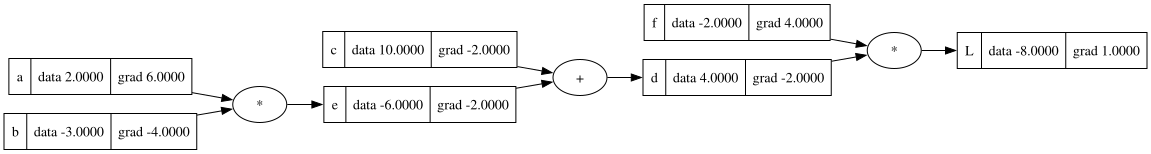

In [114]:
draw_dot(L)

In [115]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

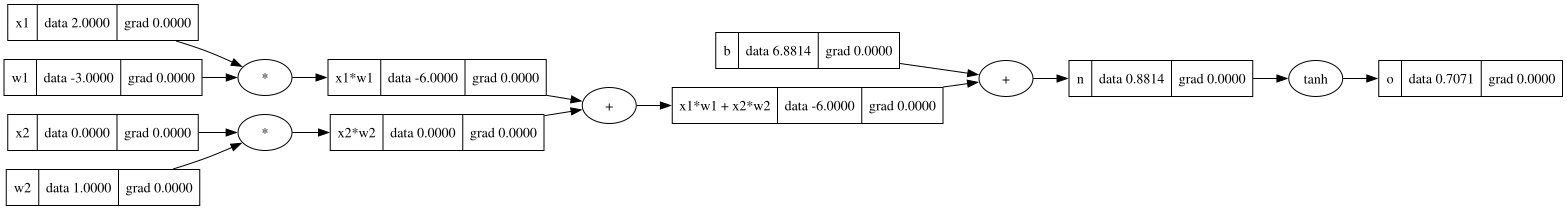

In [116]:
draw_dot(o)

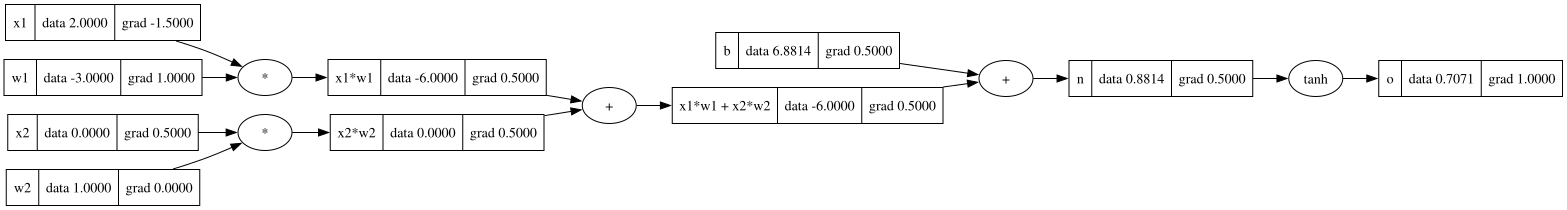

In [117]:
topo = []
visited = set()

def build_topo(v: Value):
    if v not in visited:
        visited.add(v)
        for c in v._prev:
            build_topo(c)
        topo.append(v)

build_topo(o)

o.grad = 1.0
for n in topo[::-1]:
    n._backward()

draw_dot(o)

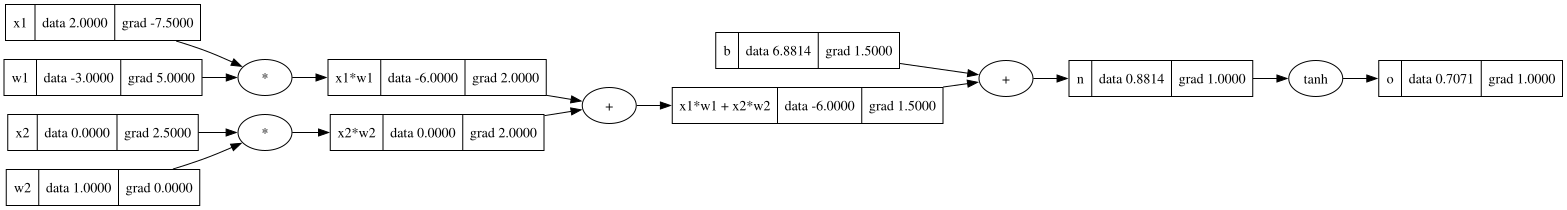

In [118]:
o.backward()
draw_dot(o)

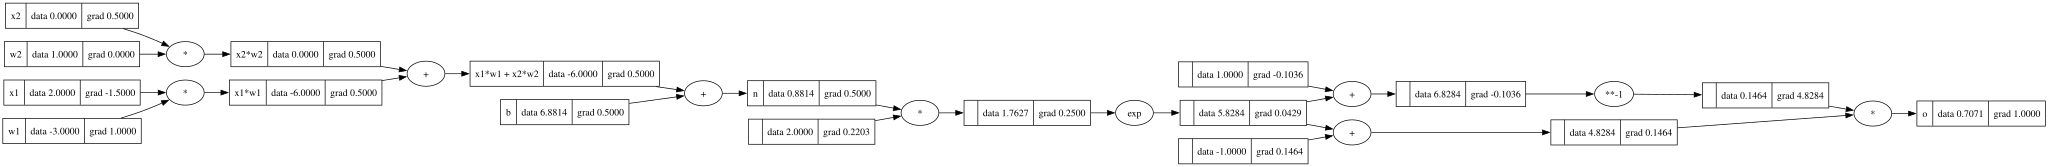

In [119]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

e = (2*n).exp()
o = (e - 1) / (e + 1)
o.label = 'o'

o.backward()
draw_dot(o)

In [165]:
class Neuron:

    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        # w * x + b
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]


class Layer:

    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        params = []
        for neuron in self.neurons:
            ps = neuron.parameters()
            params.extend(ps)
        return params


class MLP:

    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]



In [166]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4,4,1])
n(x)

Value(data=-0.5079790793983404)

In [167]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [168]:
epochs = 80
for epoch in range(epochs):
    # forward pass + loss evaluation
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    # zero grad
    for p in n.parameters():
        p.grad = 0.0

    # backward pass
    loss.backward()

    # update params
    for p in n.parameters():
        p.data += -0.05 * p.grad

    print(f"Epoch {epoch} | {epochs}: Loss {loss.data}")

Epoch 0 | 80: Loss 5.420956298454093
Epoch 1 | 80: Loss 3.0497094612380873
Epoch 2 | 80: Loss 2.4621591604914803
Epoch 3 | 80: Loss 1.800124809294751
Epoch 4 | 80: Loss 1.2146491310673446
Epoch 5 | 80: Loss 0.8248453936252039
Epoch 6 | 80: Loss 0.5923785337908535
Epoch 7 | 80: Loss 0.450104582450615
Epoch 8 | 80: Loss 0.35761841043515985
Epoch 9 | 80: Loss 0.29395670737526675
Epoch 10 | 80: Loss 0.24801230497598092
Epoch 11 | 80: Loss 0.21356004173045837
Epoch 12 | 80: Loss 0.18691030528027566
Epoch 13 | 80: Loss 0.16576434158900405
Epoch 14 | 80: Loss 0.148626964529702
Epoch 15 | 80: Loss 0.13448918982909944
Epoch 16 | 80: Loss 0.1226483085378283
Epoch 17 | 80: Loss 0.11260142419818962
Epoch 18 | 80: Loss 0.10398003813725516
Epoch 19 | 80: Loss 0.0965084993860826
Epoch 20 | 80: Loss 0.0899768279646003
Epoch 21 | 80: Loss 0.08422247151715649
Epoch 22 | 80: Loss 0.07911777211207405
Epoch 23 | 80: Loss 0.07456117575010306
Epoch 24 | 80: Loss 0.07047095101489989
Epoch 25 | 80: Loss 0.0667

In [169]:
ypred = [n(x) for x in xs]
ypred

[Value(data=0.9411563866370969),
 Value(data=-0.9409145251936192),
 Value(data=-0.9338961335217938),
 Value(data=0.9331435816728042)]